In [3]:
import pandas as pd
import json

# Open JSON file
with open("Streaming_History_Audio_2026.json", "r") as file:
    data = json.load(file)

# Convert JSON to DataFrame
df = pd.DataFrame(data)

# Save as CSV
df.to_csv("data.csv", index=False)

print("CSV file saved successfully!")

CSV file saved successfully!


In [4]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [5]:
# DATA INSPECTION
df.head()
df.isnull().sum()
df.dropna()
df.describe()

,ms_played,offline_timestamp
count,3.345000e+03,3.345000e+03
mean,1.787414e+05,1.774109e+09
std,9.808409e+04,3.135105e+06
min,0.000000e+00,1.767679e+09
25%,1.453990e+05,1.772164e+09
50%,1.892050e+05,1.774950e+09
75%,2.278790e+05,1.776594e+09
max,1.780305e+06,1.778683e+09


In [6]:
# DATA CLEANING

# converting timestamp
df['ts'] = pd.to_datetime(df['ts'])

# removing duplicates
df = df.drop_duplicates()

# removing acidental skips
df = df[df['ms_played']>30000]

In [7]:
# FEATURE ENGINEERING

df['hour'] = df['ts'].dt.hour             # hour
df['day'] = df['ts'].dt.day_name          # day
df['month'] = df['ts'].dt.month_name      # month

# minutes played
df['minutes_played'] = (df['ms_played']/60000)

master_metadata_album_artist_name
Mutoriah            126
Nikita Kering'       73
Matata               67
Doja Cat             66
Sauti Sol            56
Chris Kaiga          56
Michael Jackson      53
Ariana Grande        45
Rihanna              43
Diamond Platnumz     40
Bhad Bhabie          37
H_art the Band       35
Nicki Minaj          35
Ayra Starr           32
Toxic Lyrikali       30
Name: count, dtype: int64


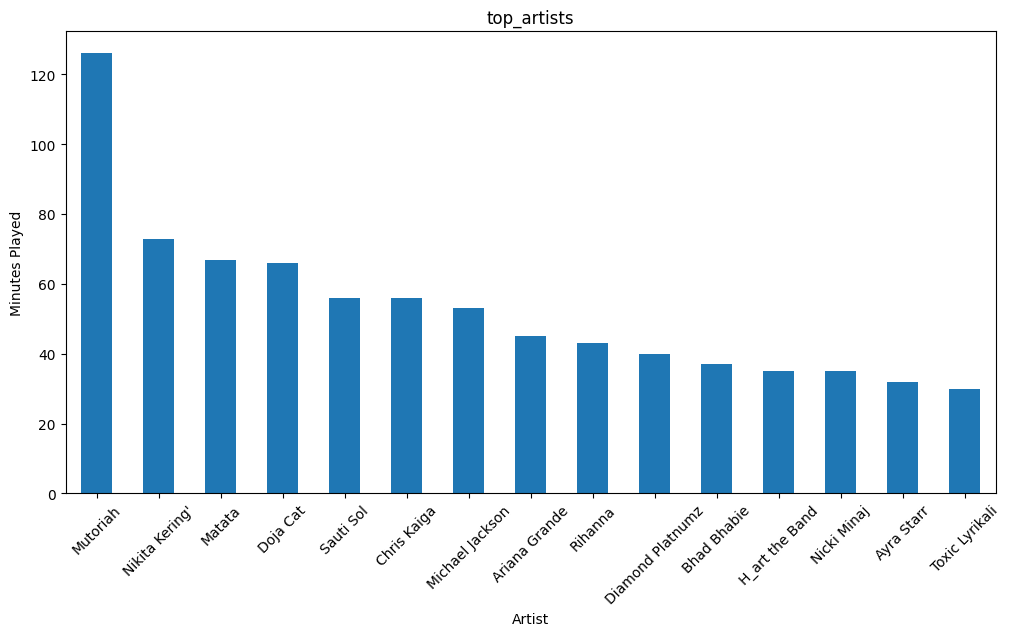

In [8]:
# TOP ARTISTS ANALYSIS AND VISUALIZATION

top_artists = (df['master_metadata_album_artist_name'].value_counts().head(15))
print(top_artists)
top_artists.plot(
    kind='bar',
    figsize=(12,6),
    title='Top Artists',
    xlabel='Artist',
    ylabel='Minutes Played',
    rot=45
)
plt.title('top_artists')
plt.show()


master_metadata_track_name
Hit Song                                     19
Vaileti                                      18
My Jaber (Friday) [feat. Brizy Annechild]    14
Mystery Lady                                 14
Smooth Criminal - 2012 Remaster              14
Rhumba                                       14
Ananipenda                                   13
Chini Chini                                  13
Agora Hills                                  13
Let Me Love You                              13
Far Rockaway                                 12
Nairobi Girl                                 12
Thathisigubhu                                12
Tosheka                                      12
Haiya                                        12
Name: count, dtype: int64


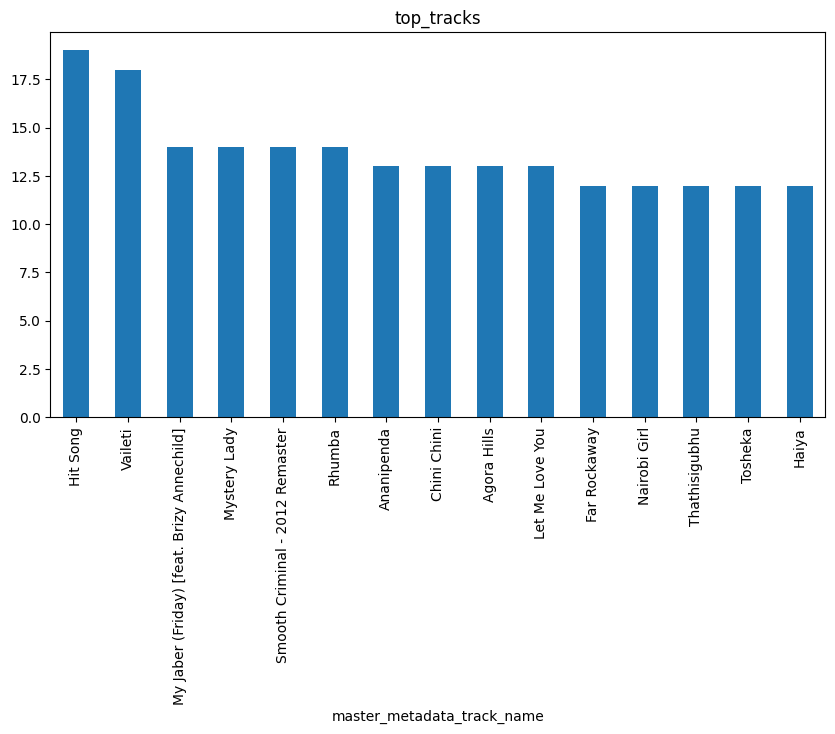

In [9]:
# TOP TRACKS ANALYSIS AND VISUALIZATION

top_tracks = (df['master_metadata_track_name'].value_counts().head(15))
print(top_tracks)
top_tracks.plot(kind='bar', figsize=(10,5))
plt.title('top_tracks')
plt.show()


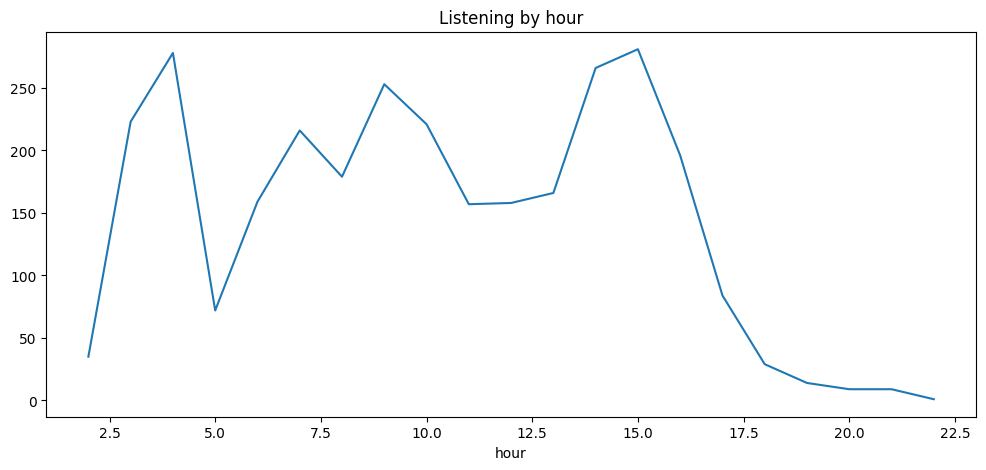

In [10]:
# listening hours
hourly = df['hour'].value_counts().sort_index()
hourly.plot(kind='line', figsize=(12,5))
plt.title('Listening by hour')
plt.show()


In [12]:
# abnormal repeats
song_repeats = (df['master_metadata_track_name'].value_counts())
abnormal_repeats = (song_repeats[song_repeats>12])
print(abnormal_repeats)

master_metadata_track_name
Hit Song                                     19
Vaileti                                      18
My Jaber (Friday) [feat. Brizy Annechild]    14
Mystery Lady                                 14
Smooth Criminal - 2012 Remaster              14
Rhumba                                       14
Ananipenda                                   13
Chini Chini                                  13
Agora Hills                                  13
Let Me Love You                              13
Name: count, dtype: int64


In [13]:
# TASTE EVOLUTION

df["year_month"] = (
    df["ts"]
    .dt.to_period("M")
    .astype(str)
)

monthly_artists = (
    df.groupby([
        "year_month",
        "master_metadata_album_artist_name"
    ])
    .size()
    .reset_index(name="streams")
)

top5 = (
    df[
        "master_metadata_album_artist_name"
    ]
    .value_counts()
    .head(5)
    .index
)

monthly_artists = monthly_artists[
    monthly_artists[
        "master_metadata_album_artist_name"
    ].isin(top5)
]
px.line(
    monthly_artists,
    x="year_month",
    y="streams",
    color="master_metadata_album_artist_name",
    title="Taste Evolution"
)

C:\Users\Naomi Bosire\AppData\Local\Temp\ipykernel_11192\1509266225.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("M")


In [ ]:
# LISTENING PERSONALITY

# 1. FEATURE ENGINEERING

from pdb import run


from pdb import run


def build_listening_features(df: pd.DataFrame) -> dict:
    df = df.copy()

    # diversity (Explorer vs Loyalist)
    unique_artists = df["master_metadata_album_artist_name"].nunique()
    total_streams = len(df)
    diversity_score = unique_artists / total_streams if total_streams else 0

    # time distribution
    morning = df[(df["hour"] >= 5) & (df["hour"] < 11)]["minutes_played"].sum()
    day = df[(df["hour"] >= 11) & (df["hour"] < 17)]["minutes_played"].sum()
    night = df[(df["hour"] >= 17) | (df["hour"] < 5)]["minutes_played"].sum()

    # skip behaviour
    skip_rate = df["skipped"].mean()
    avg_ms_played = df["ms_played"].mean()
    early_skip_rate = df[(df["skipped"] == True) & (df["ms_played"] < 30000)].shape[0] / len(df)
    long_listen_rate = df[df["ms_played"] > 120000].shape[0] / len(df)

    return {
        "diversity_score": diversity_score,
        "morning": morning,
        "day": day,
        "night": night,
        "skip_rate": skip_rate,
        "avg_ms_played": avg_ms_played,
        "early_skip_rate": early_skip_rate,
        "long_listen_rate": long_listen_rate
    }


# 2. CORE PERSONALITY TAGS

def classify_core_traits(f: dict) -> list:
    traits = []

    # Explorer vs Loyalist 
    if f["diversity_score"] > 0.15:
        traits.append("🗺️ Explorer")
    else:
        traits.append("💎 Loyalist")

    # Skip behaviour
    if f["skip_rate"] < 0.15 and f["long_listen_rate"] > 0.4:
        traits.append("🎯 Deep Listener")
    elif f["skip_rate"] > 0.4 and f["early_skip_rate"] > 0.3:
        traits.append("⚡ Picky Listener")
    else:
        traits.append("🎲 Casual Listener")

    # Time identity
    if f["morning"] >= f["day"] and f["morning"] >= f["night"]:
        traits.append("🌅 Morning Listener")
    elif f["day"] >= f["morning"] and f["day"] >= f["night"]:
        traits.append("☀️ Day Listener")
    else:
        traits.append("🌙 Night Listener")

    return traits


# 3. ARCHETYPE ENGINE

def assign_archetype(traits: list) -> tuple:
    archetypes = [
        (["🗺️ Explorer", "🌙 Night Listener"],
         "Midnight Voyager",
         "You wander through music like a city at 3am, always searching for that song that hits different."),

        (["💎 Loyalist", "🎯 Deep Listener"],
         "The Obsessive Fan",
         "You find your people and ride with them. When you love a song, you LOVE it, playlists on repeat, no shame"),

        (["🗺️ Explorer", "☀️ Day Listener"],
         "The Curated Optimist",
         "You soundtrack your days with intention. "
         "Broad taste, bright energy, you probably have a playlist for every mood."),

        (["⚡ Picky Listener", "🗺️ Explorer"],
         "The Taste Architect",
         "High standards, wide radar. "
         "You're curating the perfect soundtrack and you know instantly when something doesn't belong."),

        (["💎 Loyalist", "🌙 Night Listener"],
         "The Midnight Devotee",
         "Late nights with the same familiar sounds. Music as ritual, not background noise.")
    ]

    for match_traits, name, desc in archetypes:
        if all(t in traits for t in match_traits):
            return name, desc

    return "The Audiophile", "Your listening style is layered, unique, and hard to categorize."


# 4. MAIN PIPELINE

def generate_personality(df: pd.DataFrame):
    features = build_listening_features(df)
    traits = classify_core_traits(features)
    name, desc = assign_archetype(traits)

    return {
        "traits": traits,
        "archetype": name,
        "description": desc
    }
results = generate_personality(df)

print(f"""
╔════════════════════════════════════╗
        🎵 YOUR MUSIC DNA 🎵
╚════════════════════════════════════╝

Traits:
{chr(10).join([f"• {t}" for t in results["traits"]])}

🧬 Archetype:
{results["archetype"]}

✨ Description:
{results["description"]}
""")

In [1]:
# STREAMLIT

import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import json


st.set_page_config(
    page_title="SpotifyDNA",
    page_icon="🎧",
    layout="wide",
)

st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Syne:wght@400;600;700;800&family=DM+Sans:wght@300;400;500;600&display=swap');

html, body, [class*="css"] {
    font-family: 'DM Sans', sans-serif;
    color: #2b2b2b;
}

h1,h2,h3,h4 {
    font-family: 'Syne', sans-serif;
    color: #2b2b2b;
}

.stApp {
    background: linear-gradient(135deg, #fff7fb 0%, #f3f8ff 50%, #f7fff9 100%);
    min-height: 100vh;
}

/* Soft cards */
.metric-card {
    background: rgba(255,255,255,0.7);
    border: 1px solid rgba(0,0,0,0.05);
    border-radius: 18px;
    padding: 1.3rem 1.5rem;
    margin-bottom: 1rem;
    box-shadow: 0 6px 20px rgba(0,0,0,0.05);
}

/* Metrics */
div[data-testid="stMetricValue"] {
    color: #6c63ff !important;
    font-family: 'Syne', sans-serif;
}

/* Sidebar */
[data-testid="stSidebar"] {
    background: #ffffff !important;
    border-right: 1px solid rgba(0,0,0,0.05);
}

/* Buttons */
.stButton button {
    background: linear-gradient(90deg, #ffb6c1, #a0c4ff) !important;
    border: none !important;
    color: white !important;
    border-radius: 12px !important;
    font-weight: 600 !important;
}

.stButton button:hover {
    transform: scale(1.02);
}

/* Tabs */
.stTabs [aria-selected="true"] {
    color: #ff6f91 !important;
}

/* Hide noise */
footer { visibility: hidden; }
#MainMenu { visibility: hidden; }
</style>
""", unsafe_allow_html=True)


# ─── Sidebar ────────────────────────────────────────────────────────────────
with st.sidebar:

    st.markdown("### Upload Data")

    uploaded_files = st.file_uploader(
        "Files",
        type=["json", "csv"],
        accept_multiple_files=True
    )


# ─── APP TITLE ───────────────────────────────────────────────────────────────
st.title("🎵 Spotify Analytics App")

st.markdown("""
Analyze your Spotify listening habits,
patterns, productivity hours, artist loyalty,
taste evolution and more.
""")


# ─── DATA LOADING ────────────────────────────────────────────────────────────
@st.cache_data
def load_data(files):
    all_data = []

    for file in files:
        if file.name.endswith(".json"):
            data = json.load(file)
            temp_df = pd.DataFrame(data)
        else:
            temp_df = pd.read_csv(file)

        all_data.append(temp_df)

    return pd.concat(all_data, ignore_index=True)


def clean_data(df):
    df = df.copy()

    df['ts'] = pd.to_datetime(df['ts'], errors='coerce')
    df = df.drop_duplicates()
    df = df[df['ms_played'] > 30000]

    df['hour'] = df['ts'].dt.hour
    df['day'] = df['ts'].dt.day_name()
    df['month'] = df['ts'].dt.month_name()
    df['year'] = df['ts'].dt.year

    df['minutes_played'] = df['ms_played'] / 60000

    return df


# ─── FILE UPLOAD ─────────────────────────────────────────────────────────────
df = None

if uploaded_files:
    raw_df = load_data(uploaded_files)
    df = clean_data(raw_df)
    st.success("Data loaded successfully")


if df is not None and len(df) > 0:

    st.subheader("✨ Your Listening Identity")


    total_streams = len(df)
    unique_artists = df['master_metadata_album_artist_name'].nunique()
    total_hours = round(df['minutes_played'].sum()/60, 2)

    col1, col2, col3 = st.columns(3)

    col1.markdown(f"""
    <div style="background:rgba(255,255,255,0.7);
    padding:18px;border-radius:16px;text-align:center;
    box-shadow:0 6px 18px rgba(0,0,0,0.05)">
    🎧<br><h3>{total_streams}</h3><p>Total Streams</p>
    </div>
    """, unsafe_allow_html=True)

    col2.markdown(f"""
    <div style="background:rgba(255,255,255,0.7);
    padding:18px;border-radius:16px;text-align:center;
    box-shadow:0 6px 18px rgba(0,0,0,0.05)">
    🎤<br><h3>{unique_artists}</h3><p>Unique Artists</p>
    </div>
    """, unsafe_allow_html=True)

    col3.markdown(f"""
    <div style="background:rgba(255,255,255,0.7);
    padding:18px;border-radius:16px;text-align:center;
    box-shadow:0 6px 18px rgba(0,0,0,0.05)">
    ⏳<br><h3>{total_hours}</h3><p>Total Hours</p>
    </div>
    """, unsafe_allow_html=True)


    # ─── TOP ARTISTS ───────────────────────────────────────
    st.markdown("### 🎤 Top Artists You Can’t Escape")

    artist_df = (
        df.groupby("master_metadata_album_artist_name")["minutes_played"]
        .sum()
        .sort_values(ascending=False)
        .head(5)
    )

    for artist, mins in artist_df.items():
        st.markdown(f"""
        <div style="
            background: rgba(255,255,255,0.75);
            padding: 12px 16px;
            border-radius: 14px;
            margin-bottom: 8px;
            box-shadow: 0 4px 12px rgba(0,0,0,0.05);
            font-size: 16px;">
            🎧 <b>{artist}</b><br>
            <span style="color:#6c63ff;">{round(mins/60, 1)} hours with you</span>
        </div>
        """, unsafe_allow_html=True)


    # ─── TOP TRACKS────────────────────────────────────────
    st.markdown("### 🎶 Tracks Living in Your Head Rent-Free")

    track_df = (
        df.groupby("master_metadata_track_name")["minutes_played"]
        .sum()
        .sort_values(ascending=False)
        .head(5)
    )

    for track, mins in track_df.items():
        st.markdown(f"""
        <div style="
            background: rgba(255,255,255,0.75);
            padding: 12px 16px;
            border-radius: 14px;
            margin-bottom: 8px;
            box-shadow: 0 4px 12px rgba(0,0,0,0.05);
            font-size: 16px;">
            🎵 <b>{track}</b><br>
            <span style="color:#ff6f91;">{round(mins, 1)} min played</span>
        </div>
        """, unsafe_allow_html=True)


    # ─── HOURLY INSIGHT ───────────────────────────────────
    st.markdown("### ⏰ When You Turn Into a Music Character")

    hourly = df.groupby("hour")["minutes_played"].sum()
    peak_hour = hourly.idxmax()

    st.markdown(f"""
    <div style="
        background: linear-gradient(90deg, #a0c4ff, #ffb6c1);
        padding: 18px;
        border-radius: 18px;
        color: white;
        font-size: 16px;
        box-shadow: 0 6px 18px rgba(0,0,0,0.08);
    ">
    """)


    # ─── TASTE EVOLUTION─────────────────────
    st.markdown("### 📈 Your Taste Evolution (Top 5 Artists)")

    df["year_month"] = df["ts"].dt.to_period("M").astype(str)

    monthly_artists = (
        df.groupby(["year_month", "master_metadata_album_artist_name"])
        .size()
        .reset_index(name="streams")
    )

    top5 = df["master_metadata_album_artist_name"].value_counts().head(5).index

    monthly_artists = monthly_artists[
        monthly_artists["master_metadata_album_artist_name"].isin(top5)
    ]

    fig = px.line(
        monthly_artists,
        x="year_month",
        y="streams",
        color="master_metadata_album_artist_name",
        title=""
    )

    st.plotly_chart(fig, use_container_width=True)

    # ─── PERSONALITY ────────────────────────────────────────────────────────

    def build_listening_features(df: pd.DataFrame) -> dict:
        df = df.copy()

        unique_artists = df["master_metadata_album_artist_name"].nunique()
        total_streams = len(df)
        diversity_score = unique_artists / total_streams if total_streams else 0

        morning = df[(df["hour"] >= 5) & (df["hour"] < 11)]["minutes_played"].sum()
        day = df[(df["hour"] >= 11) & (df["hour"] < 17)]["minutes_played"].sum()
        night = df[(df["hour"] >= 17) | (df["hour"] < 5)]["minutes_played"].sum()

        skip_rate = df["skipped"].mean() if "skipped" in df.columns else 0
        avg_ms_played = df["ms_played"].mean()

        early_skip_rate = (
            df[(df["skipped"] == True) & (df["ms_played"] < 30000)].shape[0] / len(df)
            if "skipped" in df.columns and len(df) else 0
        )

        long_listen_rate = (
            df[df["ms_played"] > 120000].shape[0] / len(df)
            if len(df) else 0
        )

        return {
            "diversity_score": diversity_score,
            "morning": morning,
            "day": day,
            "night": night,
            "skip_rate": skip_rate,
            "avg_ms_played": avg_ms_played,
            "early_skip_rate": early_skip_rate,
            "long_listen_rate": long_listen_rate
        }


    def classify_core_traits(f: dict) -> list:
        traits = []

        if f["diversity_score"] > 0.15:
            traits.append("🗺️ Explorer")
        else:
            traits.append("💎 Loyalist")

        if f["skip_rate"] < 0.15 and f["long_listen_rate"] > 0.4:
            traits.append("🎯 Deep Listener")
        elif f["skip_rate"] > 0.4 and f["early_skip_rate"] > 0.3:
            traits.append("⚡ Picky Listener")
        else:
            traits.append("🎲 Casual Listener")

        if f["morning"] >= f["day"] and f["morning"] >= f["night"]:
            traits.append("🌅 Morning Listener")
        elif f["day"] >= f["morning"] and f["day"] >= f["night"]:
            traits.append("☀️ Day Listener")
        else:
            traits.append("🌙 Night Listener")

        return traits


    def assign_archetype(traits: list) -> tuple:
        archetypes = [
            (["🗺️ Explorer", "🌙 Night Listener"],
             "Midnight Voyager",
             "You wander through music like a city at 3am, always searching for that song that hits different."),

            (["💎 Loyalist", "🎯 Deep Listener"],
             "The Obsessive Fan",
             "You find your people and ride with them. When you love a song, you LOVE it, playlists on repeat."),

            (["🗺️ Explorer", "☀️ Day Listener"],
              "The Curated Optimist",
              "You soundtrack your days with intention. "
              "Broad taste, bright energy, you probably have a playlist for every mood."),

            (["⚡ Picky Listener", "🗺️ Explorer"],
              "The Taste Architect",
             "High standards, wide radar. "
             "You're curating the perfect soundtrack and you know instantly when something doesn't belong."),

            (["💎 Loyalist", "🌙 Night Listener"],
             "The Midnight Devotee",
             "Late nights with the same familiar sounds. Music as ritual, not background noise.")
        ]

        for match_traits, name, desc in archetypes:
            if all(t in traits for t in match_traits):
                return name, desc

        return "The Audiophile", "Your listening style is layered and unique."


    def generate_personality(df: pd.DataFrame):
        features = build_listening_features(df)
        traits = classify_core_traits(features)
        name, desc = assign_archetype(traits)

        return {
            "traits": traits,
            "archetype": name,
            "description": desc
        }

    results = generate_personality(df)

    st.markdown("### 🎵 Your Music DNA")

    st.write("**Traits:**")
    for t in results["traits"]:
        st.write(f"• {t}")

    st.write("**Archetype:**")
    st.write(results["archetype"])

    st.write("**Description:**")
    st.write(results["description"])

else:
    st.warning("Upload your Spotify files to begin analysis")

2026-05-22 14:23:30.239 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-22 14:23:30.239 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-22 14:23:31.372 
  command:

    streamlit run C:\Users\Naomi Bosire\AppData\Roaming\Python\Python311\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-05-22 14:23:31.373 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-22 14:23:31.374 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-22 14:23:31.374 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-22 14:23:31.374 Thread 'MainThread': missing ScriptRunContext! This warnin